In [1]:
import os
import glob
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import os

# Option A: Relative path going up 2 levels to the Thesis root
stlora_dir = os.path.abspath("../../outputs/slideredit/stlora")

# Print it out to verify it points to the right place before running the loop!
print(f"Targeting outputs at: {stlora_dir}")
print(f"Exists? {os.path.exists(stlora_dir)}")

Targeting outputs at: c:\Users\oikoh\1Coding\Thesis\outputs\slideredit\stlora
Exists? True


## Cosine Similarity (Custom Heuristic)

In [3]:
# 1. Resolve path relative to Thesis root
# Notebook location: Thesis/SliderEdit/benchmarks/
# Outputs location: Thesis/outputs/slideredit/stlora
stlora_dir = os.path.abspath("../../outputs/slideredit/stlora")

if not os.path.exists(stlora_dir):
    raise FileNotFoundError(f"Directory not found: {stlora_dir}. Double-check that your benchmark run completed and saved images there!")

# 2. Load lightweight feature extractor (DINOv2)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_feature(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = model(tensor)
    return F.normalize(feature, dim=-1)

def compute_grid_disentanglement(exp_folder):
    files = glob.glob(os.path.join(exp_folder, "*.png"))
    if not files:
        return None, None
    
    # Locate anchor (0.0, 0.0), S1-only shift (1.0, 0.0), S2-only shift (0.0, 1.0)
    try:
        path_origin = [f for f in files if "0.00_" in f and f.endswith("0.00.png")][0]
        path_s1 = [f for f in files if ("1.00_" in f or "pos_1.00_" in f) and f.endswith("0.00.png")][0]
        path_s2 = [f for f in files if "0.00_" in f and (f.endswith("1.00.png") or f.endswith("pos_1.00.png"))][0]
    except IndexError:
        # Fallback if filename formatting differs
        return None, None

    # Feature representations
    feat_origin = extract_feature(path_origin)
    feat_s1 = extract_feature(path_s1)
    feat_s2 = extract_feature(path_s2)

    # Edit direction vectors
    dir_s1 = F.normalize(feat_s1 - feat_origin, dim=-1)
    dir_s2 = F.normalize(feat_s2 - feat_origin, dim=-1)

    # Cosine similarity (0 = perfectly orthogonal / no interference)
    cos_sim = torch.mm(dir_s1, dir_s2.T).item()
    disentanglement_score = 1.0 - abs(cos_sim)
    
    return cos_sim, disentanglement_score


Using cache found in C:\Users\oikoh/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\oikoh/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\oikoh/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\oikoh/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


### Run Disentanglement Metric Script

In [4]:
# 3. Compute metric across all STLoRA experiment folders
results = []
print(f"Analyzing STLoRA experiments in: {stlora_dir}\n" + "-"*50)

for exp_name in sorted(os.listdir(stlora_dir)):
    exp_path = os.path.join(stlora_dir, exp_name)
    if os.path.isdir(exp_path):
        cos_sim, score = compute_grid_disentanglement(exp_path)
        if cos_sim is not None:
            results.append({"ID": exp_name, "Cosine_Sim": cos_sim, "Disentanglement": score})
            print(f"[{exp_name}] Vector Cosine Sim: {cos_sim:+.4f} | Disentanglement Score: {score:.4f}")

if results:
    avg_sim = np.mean([r["Cosine_Sim"] for r in results])
    avg_score = np.mean([r["Disentanglement"] for r in results])
    print("-" * 50)
    print(f"AVERAGE ACROSS SUITE:")
    print(f"Mean Vector Coupling (Cosine Sim): {avg_sim:+.4f} (Close to 0 = High Independence)")
    print(f"Mean Disentanglement Index:       {avg_score:.4f} / 1.0000")

Analyzing STLoRA experiments in: c:\Users\oikoh\1Coding\Thesis\outputs\slideredit\stlora
--------------------------------------------------
[fashion_01] Vector Cosine Sim: +0.2390 | Disentanglement Score: 0.7610
[fashion_03] Vector Cosine Sim: +0.5653 | Disentanglement Score: 0.4347
[portrait_02] Vector Cosine Sim: +0.0248 | Disentanglement Score: 0.9752
[portrait_04] Vector Cosine Sim: +0.2425 | Disentanglement Score: 0.7575
[product_03] Vector Cosine Sim: +0.0230 | Disentanglement Score: 0.9770
[scene_01] Vector Cosine Sim: -0.0834 | Disentanglement Score: 0.9166
[scene_02] Vector Cosine Sim: +0.0243 | Disentanglement Score: 0.9757
[scene_03] Vector Cosine Sim: -0.3258 | Disentanglement Score: 0.6742
[typo_05] Vector Cosine Sim: +0.0109 | Disentanglement Score: 0.9891
--------------------------------------------------
AVERAGE ACROSS SUITE:
Mean Vector Coupling (Cosine Sim): +0.0801 (Close to 0 = High Independence)
Mean Disentanglement Index:       0.8290 / 1.0000


### Plot

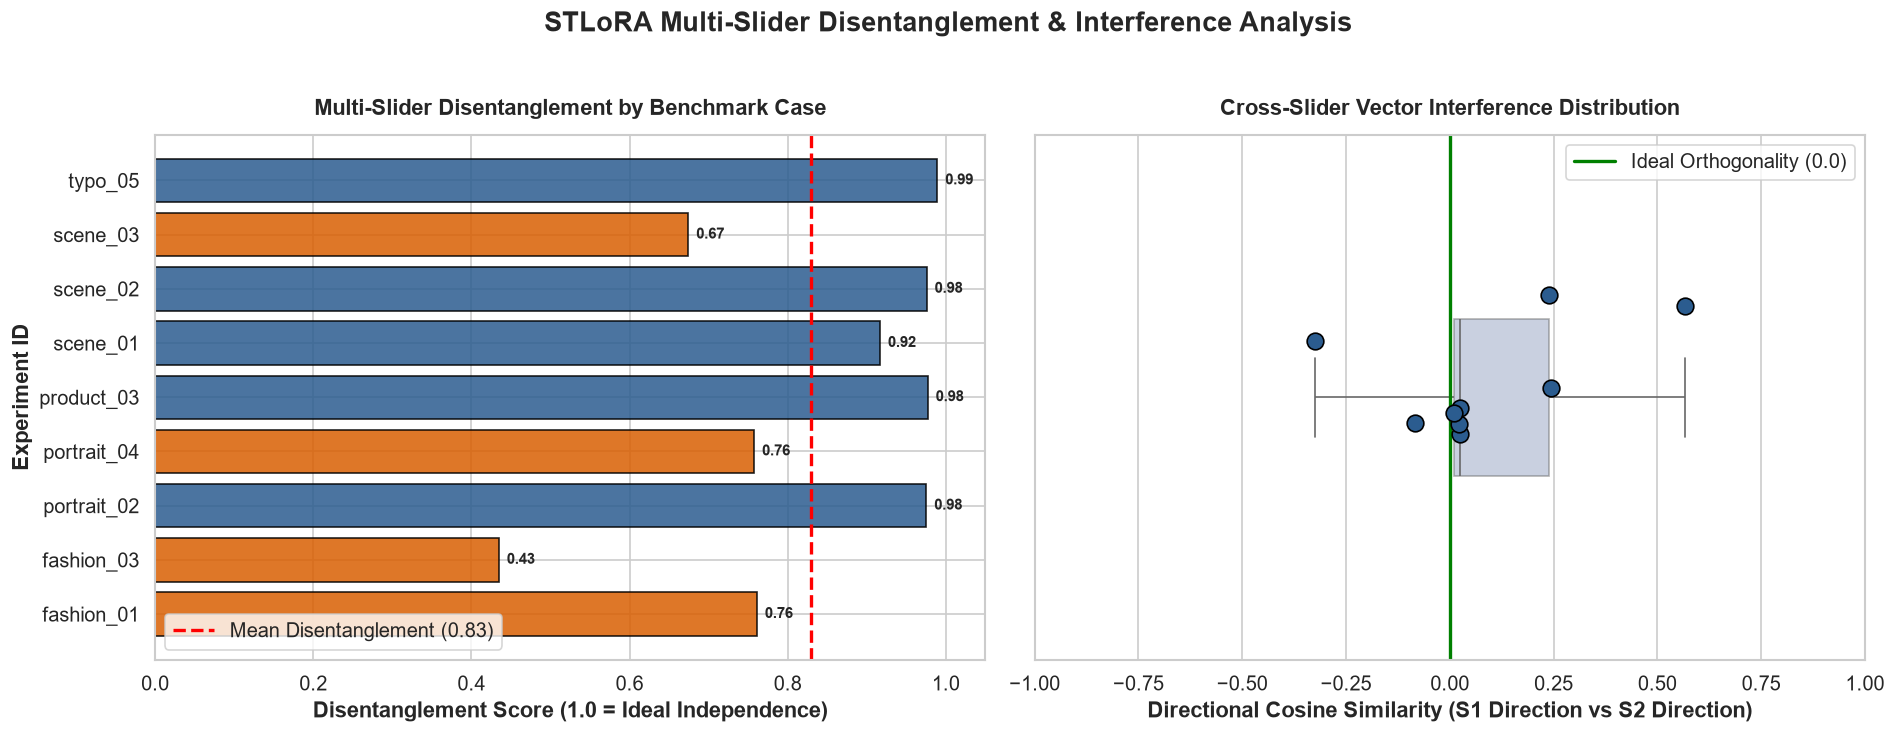

In [5]:
# Convert results list to pandas DataFrame
df_res = pd.DataFrame(results)

# If no results found, throw a helpful warning
if df_res.empty:
    print("No valid grid images found to plot! Check that files exist in outputs.")
else:
    # Set global plotting style
    sns.set_theme(style="whitegrid", font_scale=1.1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

    # -------------------------------------------------------------------------
    # Plot 1: Disentanglement Score per Test Case
    # -------------------------------------------------------------------------
    colors = ['#2b5c8f' if score >= 0.8 else '#d95f02' for score in df_res['Disentanglement']]
    
    bars = axes[0].barh(df_res['ID'], df_res['Disentanglement'], color=colors, edgecolor='black', alpha=0.85)
    axes[0].axvline(x=df_res['Disentanglement'].mean(), color='red', linestyle='--', linewidth=2, 
                    label=f"Mean Disentanglement ({df_res['Disentanglement'].mean():.2f})")
    
    axes[0].set_xlim(0, 1.05)
    axes[0].set_xlabel("Disentanglement Score (1.0 = Ideal Independence)", fontweight='bold')
    axes[0].set_ylabel("Experiment ID", fontweight='bold')
    axes[0].set_title("Multi-Slider Disentanglement by Benchmark Case", fontweight='bold', pad=12)
    axes[0].legend(loc="lower left")

    # Annotate bar values
    for bar in bars:
        width = bar.get_width()
        axes[0].text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                     va='center', ha='left', fontsize=9, fontweight='bold')

    # -------------------------------------------------------------------------
    # Plot 2: Cosine Similarity Interference Range (Orthogonality Check)
    # -------------------------------------------------------------------------
    sns.stripplot(data=df_res, x="Cosine_Sim", ax=axes[1], size=10, color="#2b5c8f", jitter=0.2, edgecolor="black", linewidth=1)
    sns.boxplot(data=df_res, x="Cosine_Sim", ax=axes[1], color="#8da0cb", width=0.3, boxprops=dict(alpha=0.5))

    axes[1].axvline(x=0.0, color='green', linestyle='-', linewidth=2, label="Ideal Orthogonality (0.0)")
    axes[1].set_xlim(-1.0, 1.0)
    axes[1].set_xlabel("Directional Cosine Similarity (S1 Direction vs S2 Direction)", fontweight='bold')
    axes[1].set_title("Cross-Slider Vector Interference Distribution", fontweight='bold', pad=12)
    axes[1].legend(loc="upper right")

    plt.suptitle("STLoRA Multi-Slider Disentanglement & Interference Analysis", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### Messy Data Evaluation

Scanning images in: c:\Users\oikoh\1Coding\Thesis\outputs\slideredit\stlora


Using cache found in C:\Users\oikoh/.cache\torch\hub\facebookresearch_dinov2_main


Successfully parsed 194 image files across 43 experiment groups!

[add_tattoos_to_the_person | make_th...] Cosine Sim: -0.1500 | Disentanglement: 0.8500
[add_tattoos_to_the_person | make_th...] Cosine Sim: +0.1499 | Disentanglement: 0.8501
[fashion_01_change_the_tshirt_materi...] Cosine Sim: +0.2390 | Disentanglement: 0.7610
[fashion_03_extend_the_shoe_collar_h...] Cosine Sim: +0.5653 | Disentanglement: 0.4347
[make_the_background_sunset_red | ma...] Cosine Sim: +0.0404 | Disentanglement: 0.9596
[make_the_person_older | make_the_ha...] Cosine Sim: -0.0453 | Disentanglement: 0.9547
[make_the_surface_metallic | make_th...] Cosine Sim: +0.2209 | Disentanglement: 0.7791
[make_the_text_font_serif | make_the...] Cosine Sim: -0.0360 | Disentanglement: 0.9640
[portrait_02_change_the_persons_hair...] Cosine Sim: +0.0248 | Disentanglement: 0.9752
[portrait_04_change_the_persons_faci...] Cosine Sim: +0.2425 | Disentanglement: 0.7575
[product_03_change_the_camera_body_f...] Cosine Sim: +0.0230 | D

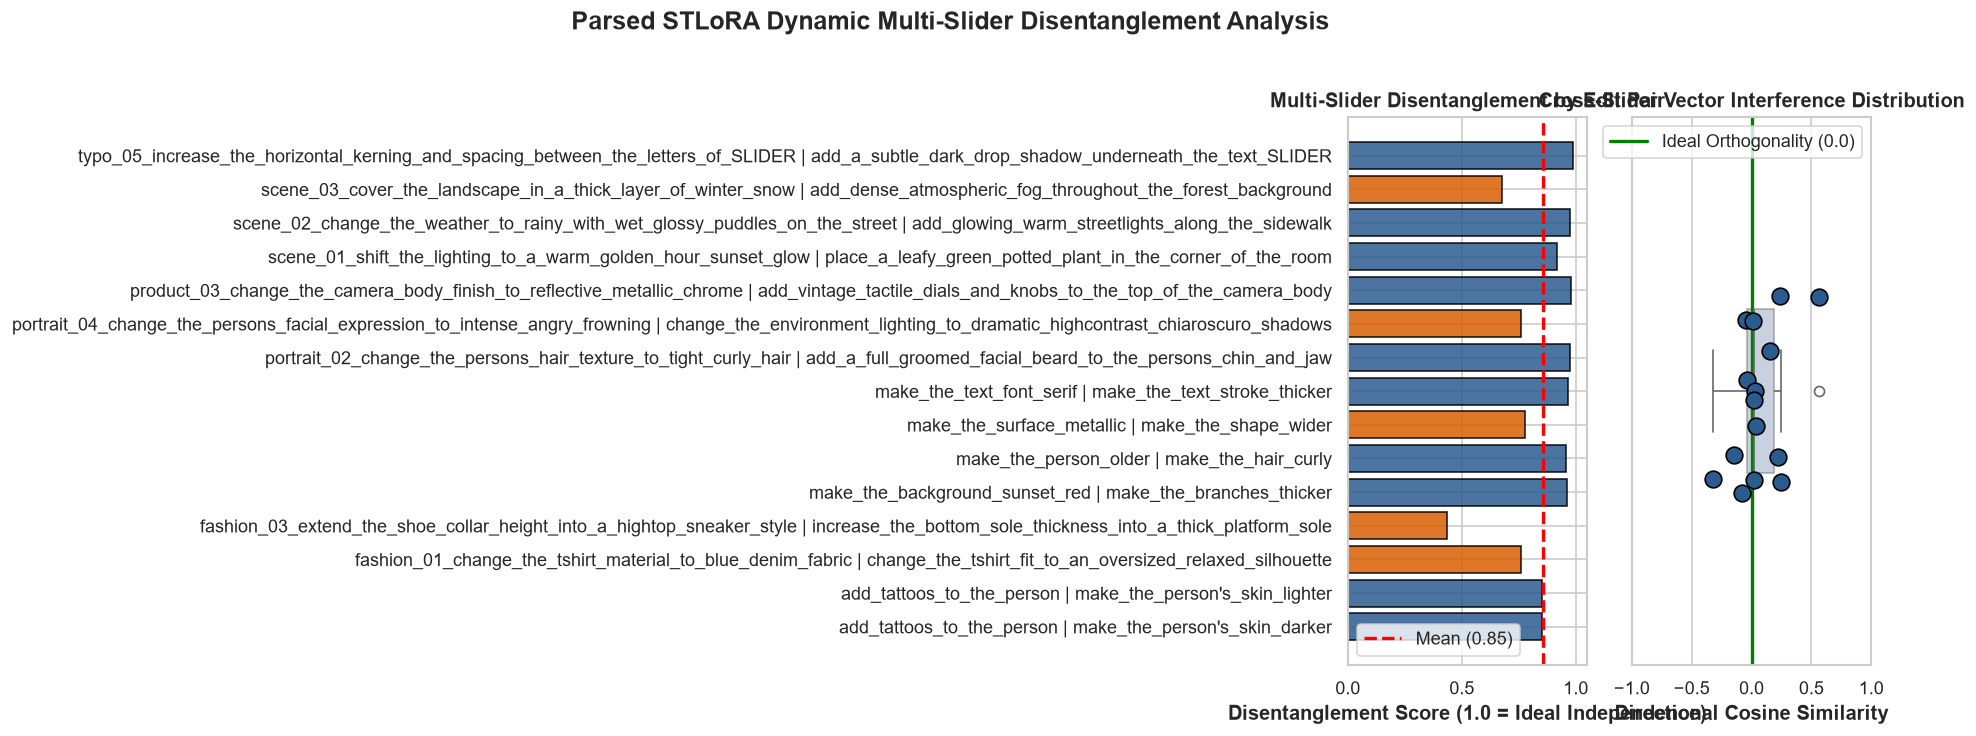

In [ ]:
import os
import re
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns



# -----------------------------------------------------------------------------
# 1. Path Setup (Adapts to Thesis/SliderEdit/benchmarks/this-notebook)
# -----------------------------------------------------------------------------
stlora_dir = os.path.abspath("../../outputs/slideredit/stlora")
print(f"Scanning images in: {stlora_dir}")

# -----------------------------------------------------------------------------
# 2. DINOv2 Feature Extractor Setup
# -----------------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device).eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_feature(img_path):
    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feature = model(tensor)
    return F.normalize(feature, dim=-1)

# -----------------------------------------------------------------------------
# 3. Parse Filenames & Group by Experiment Types
# -----------------------------------------------------------------------------
# Regex pattern to capture: edit1, alpha1, edit2, alpha2
# Matches float values including negative numbers (e.g. -1.0, 0.0, 1.0, neg_1.00)
filename_pattern = re.compile(r"^(?P<e1>.+)_(?P<a1>-?\d+\.?\d*|neg_\d+\.?\d*)_(?P<e2>.+)_(?P<a2>-?\d+\.?\d*|neg_\d+\.?\d*)\.png$")

all_image_files = glob.glob(os.path.join(stlora_dir, "**", "*.png"), recursive=True)

parsed_records = []

for filepath in all_image_files:
    filename = os.path.basename(filepath)
    match = filename_pattern.match(filename)
    if match:
        data = match.groupdict()
        
        # Helper to convert alpha strings to standard floats
        def parse_alpha(val_str):
            cleaned = val_str.replace("neg_", "-")
            return float(cleaned)

        parsed_records.append({
            'filepath': filepath,
            'edit_1': data['e1'],
            'alpha_1': parse_alpha(data['a1']),
            'edit_2': data['e2'],
            'alpha_2': parse_alpha(data['a2']),
            'group_key': f"{data['e1']} | {data['e2']}"
        })

df_files = pd.DataFrame(parsed_records)
print(f"Successfully parsed {len(df_files)} image files across {df_files['group_key'].nunique()} experiment groups!\n")

# -----------------------------------------------------------------------------
# 4. Compute Disentanglement Metric Per Group
# -----------------------------------------------------------------------------
eval_results = []

for group_name, group_df in df_files.groupby('group_key'):
    # Look for origin (0,0) and single-axis edit images
    # We use tolerance or absolute max positive values if exact 1.0 doesn't exist
    origin_file = group_df[(group_df['alpha_1'] == 0.0) & (group_df['alpha_2'] == 0.0)]
    
    # Get max positive scale image for Edit 1 (e.g., alpha_1 = 1.0, alpha_2 = 0.0)
    s1_file = group_df[(group_df['alpha_1'] > 0.0) & (group_df['alpha_2'] == 0.0)].sort_values('alpha_1', ascending=False)
    
    # Get max positive scale image for Edit 2 (e.g., alpha_1 = 0.0, alpha_2 = 1.0)
    s2_file = group_df[(group_df['alpha_1'] == 0.0) & (group_df['alpha_2'] > 0.0)].sort_values('alpha_2', ascending=False)

    if not origin_file.empty and not s1_file.empty and not s2_file.empty:
        p_origin = origin_file.iloc[0]['filepath']
        p_s1 = s1_file.iloc[0]['filepath']
        p_s2 = s2_file.iloc[0]['filepath']

        # Extract DINOv2 feature vectors
        f_origin = extract_feature(p_origin)
        f_s1 = extract_feature(p_s1)
        f_s2 = extract_feature(p_s2)

        # Edit direction vectors
        dir_s1 = F.normalize(f_s1 - f_origin, dim=-1)
        dir_s2 = F.normalize(f_s2 - f_origin, dim=-1)

        # Directional Cosine Similarity (0.0 = ideal independence)
        cos_sim = torch.mm(dir_s1, dir_s2.T).item()
        disentanglement = 1.0 - abs(cos_sim)

        eval_results.append({
            'Experiment_Group': group_name,
            'Cosine_Sim': cos_sim,
            'Disentanglement': disentanglement
        })
        print(f"[{group_name[:35]}...] Cosine Sim: {cos_sim:+.4f} | Disentanglement: {disentanglement:.4f}")

# -----------------------------------------------------------------------------
# 5. Plot Grouped Results
# -----------------------------------------------------------------------------
df_eval = pd.DataFrame(eval_results)

if not df_eval.empty:
    sns.set_theme(style="whitegrid", font_scale=1.0)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

    # Bar chart of scores per edit pair
    colors = ['#2b5c8f' if s >= 0.8 else '#d95f02' for s in df_eval['Disentanglement']]
    bars = axes[0].barh(df_eval['Experiment_Group'], df_eval['Disentanglement'], color=colors, edgecolor='black', alpha=0.85)
    axes[0].axvline(x=df_eval['Disentanglement'].mean(), color='red', linestyle='--', linewidth=2, 
                    label=f"Mean ({df_eval['Disentanglement'].mean():.2f})")
    axes[0].set_xlim(0, 1.05)
    axes[0].set_xlabel("Disentanglement Score (1.0 = Ideal Independence)", fontweight='bold')
    axes[0].set_title("Multi-Slider Disentanglement by Edit Pair", fontweight='bold')
    axes[0].legend(loc="lower left")

    # Interference Distribution
    sns.stripplot(data=df_eval, x="Cosine_Sim", ax=axes[1], size=10, color="#2b5c8f", jitter=0.2, edgecolor="black", linewidth=1)
    sns.boxplot(data=df_eval, x="Cosine_Sim", ax=axes[1], color="#8da0cb", width=0.3, boxprops=dict(alpha=0.5))
    axes[1].axvline(x=0.0, color='green', linestyle='-', linewidth=2, label="Ideal Orthogonality (0.0)")
    axes[1].set_xlim(-1.0, 1.0)
    axes[1].set_xlabel("Directional Cosine Similarity", fontweight='bold')
    axes[1].set_title("Cross-Slider Vector Interference Distribution", fontweight='bold')
    axes[1].legend(loc="upper right")

    plt.suptitle("Parsed STLoRA Dynamic Multi-Slider Disentanglement Analysis", fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No complete (0,0), (1,0), (0,1) image trios found. Ensure images with alpha values of 0.0 and positive edits exist in stlora!")

## SliderEdit Disentanglement Metric

In [9]:
import os
import sys
import glob
import math
import re
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

from slideredit.pipelines import SliderEditFluxKontextPipeline
from evaluation import (
    CLIPEvaluator,
    SiglipEvaluator,
    BLIPEvaluator,
    LPIPSFeatureDistanceEvaluator,
    DiNOFeatureDistanceEvaluator,
    FaceIdentityDistanceEvaluator,
)
from evaluation.utils import normalize_to_unit_interval, chi_square_1d

In [10]:
CSV_METADATA_PATH = "../../datasets/experiments24-7.csv"
ORIGINAL_IMAGES_DIR = "../../datasets/test_images"
GENERATIONS_DIR = "../../outputs/slideredit/stlora"

OUTPUT_CSV_PATH = "./eval_results_disentanglement.csv"

# Choose which column from experiments24-7.csv represents the target attribute for VLM evaluation
# "subprompt_2" is typically the target edit prompt (e.g. "increase the letter outline...")
TARGET_PROMPT_COLUMN = "subprompt_2"

In [11]:
def parse_alpha_from_filename(filename: str) -> float:
    """Extracts numeric alpha/scale value from filenames like 'alpha_1.5.png', '-2.0.jpg', etc."""
    match = re.search(r"(?:alpha|scale|val)?[=_]?(-?\d+\.?\d*)", filename, re.IGNORECASE)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass
    raise ValueError(f"Could not parse alpha value from filename: {filename}")

In [12]:
print(f"Loading metadata from {CSV_METADATA_PATH}...")
if not os.path.exists(CSV_METADATA_PATH):
    raise FileNotFoundError(f"CSV file not found at {CSV_METADATA_PATH}")

df_meta = pd.read_csv(CSV_METADATA_PATH)
# Create a lookup dictionary mapping image 'id' -> row dictionary
meta_lookup = df_meta.set_index("id").to_dict(orient="index")
print(f"Loaded {len(meta_lookup)} ID metadata records successfully.")

Loading metadata from ../../datasets/experiments24-7.csv...
Loaded 20 ID metadata records successfully.


In [4]:
# --- 2. EVALUATOR INITIALIZATION ---
print("Loading evaluators...")
vlm_evaluators = {
    "CLIP": CLIPEvaluator(),
    "Siglip": SiglipEvaluator(),
    "BLIP": BLIPEvaluator(),
}

feature_distance_evaluators = {
    "LPIPS_vgg": LPIPSFeatureDistanceEvaluator(net="vgg"),
    "LPIPS_alex": LPIPSFeatureDistanceEvaluator(net="alex"),
    "DiNOv2": DiNOFeatureDistanceEvaluator(),
    "FaceID": FaceIdentityDistanceEvaluator(), # Measures identity preservation (Disentanglement)
}
print("Evaluators loaded successfully!")

Loading evaluators...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 49282.11it/s]
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 472/472 [00:00<00:00, 31103.09it/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\oikoh\1Coding\Thesis\SliderEdit\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\oikoh\1Coding\Thesis\SliderEdit\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\oikoh/.cache\torch\hub\checkpoints\vgg16-397923af.pth


...

Loading model from: c:\Users\oikoh\1Coding\Thesis\SliderEdit\venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


c:\Users\oikoh\1Coding\Thesis\SliderEdit\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\oikoh\.cache\huggingface\hub\models--facebook--dinov2-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 223

download_path: C:\Users\oikoh/.insightface\models\buffalo_l


100%|██████████| 281857/281857 [00:25<00:00, 10850.50KB/s]
c:\Users\oikoh\1Coding\Thesis\SliderEdit\venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\oikoh/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\oikoh/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\oikoh/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\oikoh/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\oikoh/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

In [13]:
def evaluate_dataset():
    # Find all subdirectories in GENERATIONS_DIR matching 'id'
    id_dirs = [d for d in os.listdir(GENERATIONS_DIR) if os.path.isdir(os.path.join(GENERATIONS_DIR, d))]
    
    results = []

    for id_name in tqdm(id_dirs, desc="Evaluating IDs"):
        # Check if ID exists in metadata
        if id_name not in meta_lookup:
            print(f"Warning: ID '{id_name}' not found in {CSV_METADATA_PATH}. Skipping.")
            continue
            
        id_info = meta_lookup[id_name]
        target_prompt = id_info.get(TARGET_PROMPT_COLUMN, "")
        base_prompt = id_info.get("base_prompt", "")
        
        # Locate reference image in test_images
        ref_path = os.path.join(ORIGINAL_IMAGES_DIR, f"{id_name}.png")
        if not os.path.exists(ref_path):
            ref_path = os.path.join(ORIGINAL_IMAGES_DIR, f"{id_name}.jpg")
            if not os.path.exists(ref_path):
                print(f"Warning: Reference image for {id_name} not found in {ORIGINAL_IMAGES_DIR}. Skipping.")
                continue
                
        ref_image = Image.open(ref_path).convert("RGB")
        
        gen_dir_path = Path(os.path.join(GENERATIONS_DIR, id_name)).resolve()
        gen_image_paths = sorted(list(gen_dir_path.glob("*.png")) + list(gen_dir_path.glob("*.jpg")))

        for gen_path in gen_image_paths:
            filename = os.path.basename(gen_path)
            abs_path = str(gen_path)
            
            if os.name == 'nt' and not abs_path.startswith('\\\\?\\'):
                abs_path = '\\\\?\\' + abs_path
                
            try:
                alpha = parse_alpha_from_filename(filename)
            except ValueError as e:
                print(f"Skipping {filename}: {e}")
                continue

            gen_image = Image.open(abs_path).convert("RGB")
            
            record = {
                "id_name": id_name,
                "domain": id_info.get("domain", ""),
                "file_name": filename,
                "alpha": alpha,
                "target_prompt": target_prompt,
                "base_prompt": base_prompt,
            }

            # --- Target Attribute Score (Alignment/Strength) ---
            for name, evaluator in vlm_evaluators.items():
                record[f"VLM_{name}"] = evaluator.get_score(gen_image, target_prompt)

            # --- Identity & Feature Distance Metrics (Disentanglement) ---
            for name, evaluator in feature_distance_evaluators.items():
                record[f"Dist_{name}"] = evaluator.get_distance(ref_image, gen_image)

            results.append(record)

    df_results = pd.DataFrame(results)
    df_results.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"Results saved to {OUTPUT_CSV_PATH}")
    return df_results

In [14]:
def plot_results(results_dict, alpha_values, title, ncols, ylabel, marker="o"):
    names = list(results_dict.keys())
    nrows = math.ceil(len(names) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
    
    for idx, name in enumerate(names):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        ax.plot(alpha_values, results_dict[name], marker=marker)
        ax.set_title(name)
        ax.set_xlabel("slider_alpha")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", alpha=0.5)
        
    for idx in range(len(names), nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].axis("off")
        
    fig.suptitle(title, fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()

Evaluating IDs:   0%|          | 0/10 [00:00<?, ?it/s]c:\Users\oikoh\1Coding\Thesis\SliderEdit\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Evaluating IDs:  10%|█         | 1/10 [00:36<05:25, 36.13s/it]

Evaluating IDs:  20%|██        | 2/10 [01:09<04:36, 34.59s/it]

Evaluating IDs:  40%|████      | 4/10 [02:21<03:32, 35.42s/it]

Evaluating IDs:  50%|█████     | 5/10 [02:54<02:53, 34.69s/it]

Evaluating IDs:  60%|██████    | 6/10 [03:28<02:16, 34.22s/it]

Evaluating IDs:  70%|███████   | 7/10 [04:01<01:41, 33.95s/it]

Evaluating IDs:  80%|████████  | 8/10 [04:34<01:07, 33.76s/it]

Evaluating IDs:  90%|█████████ | 9/10 [04:38<00:24, 24.37s/it]

Evaluating IDs: 100%|██████████| 10/10 [05:11<00:00, 31.19s/it]

Results saved to ./eval_results_disentanglement.csv


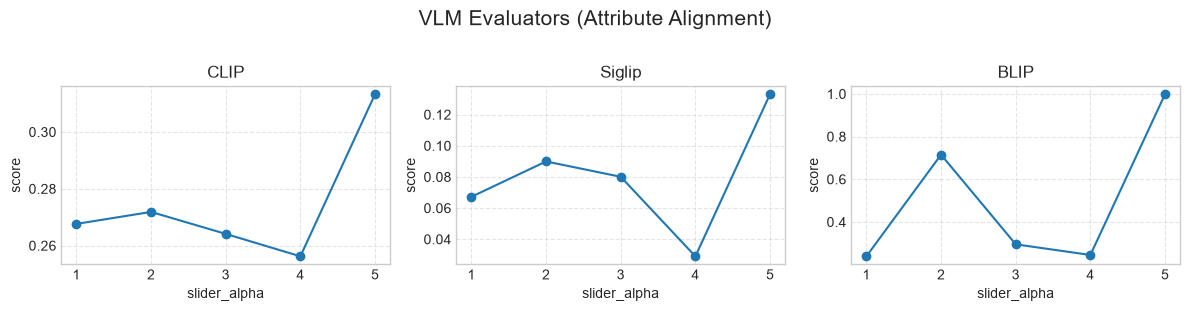

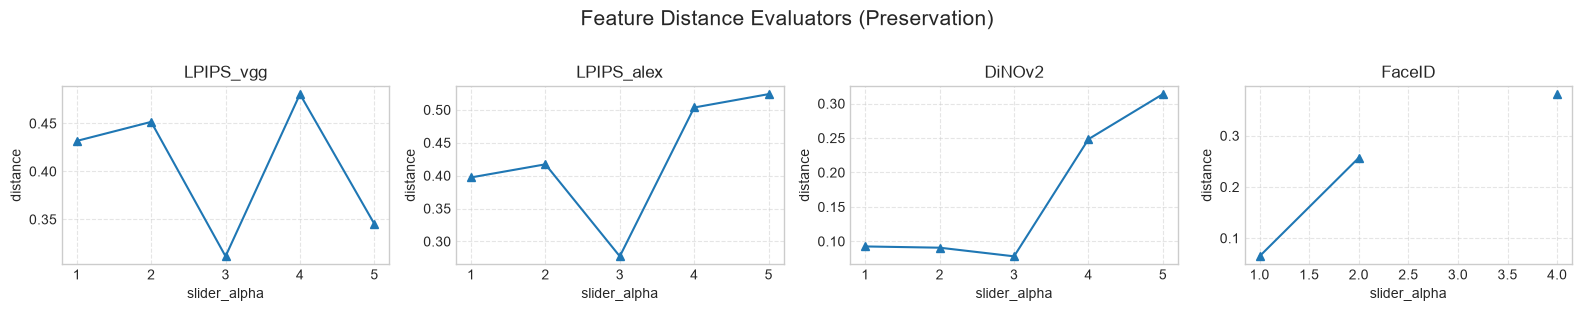

In [15]:
df_results = evaluate_dataset()

if not df_results.empty:
    # Sort by alpha for linear line plots
    df_results = df_results.sort_values(by="alpha")
    alpha_values = sorted(df_results["alpha"].unique())

    # Aggregate mean scores across all IDs for each alpha value
    vlm_cols = [c for c in df_results.columns if c.startswith("VLM_")]
    vlm_evaluator_res = {
        col.replace("VLM_", ""): df_results.groupby("alpha")[col].mean().tolist()
        for col in vlm_cols
    }

    dist_cols = [c for c in df_results.columns if c.startswith("Dist_")]
    feature_distance_evaluator_res = {
        col.replace("Dist_", ""): df_results.groupby("alpha")[col].mean().tolist()
        for col in dist_cols
    }

    # Plot metrics over slider_alpha
    plot_results(vlm_evaluator_res, alpha_values, "VLM Evaluators (Attribute Alignment)", ncols=3, ylabel="score")
    plot_results(feature_distance_evaluator_res, alpha_values, "Feature Distance Evaluators (Preservation)", ncols=4, ylabel="distance", marker="^")

In [7]:
# --- 4. DISENTANGLEMENT METRIC AGGREGATION & VISUALIZATION ---
def summarize_metrics(df):
    print("\n================ EVALUATION SUMMARY ================")
    print("1. Attribute Alignment Scores (Higher = Better target control):")
    vlm_cols = [c for c in df.columns if c.startswith("VLM_")]
    print(df[vlm_cols].mean().to_string())

    print("\n2. Disentanglement & Preservations Metrics (Lower = Better preservation):")
    dist_cols = [c for c in df.columns if c.startswith("Dist_")]
    print(df[dist_cols].mean().to_string())
    print("====================================================")

summarize_metrics(df_results)


================ EVALUATION SUMMARY ================
1. Attribute Alignment Scores (Higher = Better target control):
VLM_CLIP      0.159813
VLM_Siglip   -0.025012
VLM_BLIP      0.013651

2. Disentanglement & Preservations Metrics (Lower = Better preservation):
Dist_LPIPS_vgg     0.392556
Dist_LPIPS_alex    0.387972
Dist_DiNOv2        0.128793
Dist_FaceID        0.234180
